# Regresi Linier Sederhana: Ukuran Mesin terhadap Harga Mobil

**Dataset:** Car Price Prediction (Kaggle). Dari file asli `CarPrice_Assignment.csv` hanya diambil 2 kolom, yaitu `enginesize` dan `price`, lalu disimpan sebagai `car_price.csv`.

- **Variabel bebas (X):** `enginesize` = ukuran / kapasitas mesin mobil (cubic inch)
- **Variabel terikat (y):** `price` = harga mobil (dolar AS)

Tujuan: melihat apakah ukuran mesin memiliki keterikatan yang tinggi dengan harga mobil, lalu melatih model regresi linier untuk memprediksi harga mobil berdasarkan ukuran mesinnya.

## 1) IMPORT LIBRARIES AND DATASETS

In [4]:
# Import Pkgs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from google.colab import files
files.upload()

Saving car_price.csv to car_price.csv


{'car_price.csv': b'enginesize,price\n130,13495.0\n130,16500.0\n152,16500.0\n109,13950.0\n136,17450.0\n136,15250.0\n136,17710.0\n136,18920.0\n131,23875.0\n131,17859.167\n108,16430.0\n108,16925.0\n164,20970.0\n164,21105.0\n164,24565.0\n209,30760.0\n209,41315.0\n209,36880.0\n61,5151.0\n90,6295.0\n90,6575.0\n90,5572.0\n90,6377.0\n98,7957.0\n90,6229.0\n90,6692.0\n90,7609.0\n98,8558.0\n122,8921.0\n156,12964.0\n92,6479.0\n92,6855.0\n79,5399.0\n92,6529.0\n92,7129.0\n92,7295.0\n92,7295.0\n110,7895.0\n110,9095.0\n110,8845.0\n110,10295.0\n110,12945.0\n110,10345.0\n111,6785.0\n90,8916.5\n90,8916.5\n119,11048.0\n258,32250.0\n258,35550.0\n326,36000.0\n91,5195.0\n91,6095.0\n91,6795.0\n91,6695.0\n91,7395.0\n70,10945.0\n70,11845.0\n70,13645.0\n80,15645.0\n122,8845.0\n122,8495.0\n122,10595.0\n122,10245.0\n122,10795.0\n122,11245.0\n140,18280.0\n134,18344.0\n183,25552.0\n183,28248.0\n183,28176.0\n183,31600.0\n234,34184.0\n234,35056.0\n308,40960.0\n304,45400.0\n140,16503.0\n92,5389.0\n92,6189.0\n92,6669.0

In [8]:
# read the csv file
car_df = pd.read_csv('car_price.csv')

In [ ]:
car_df

,enginesize,price
0,130,13495.0
1,130,16500.0
2,152,16500.0
3,109,13950.0
4,136,17450.0
...,...,...
200,141,16845.0
201,141,19045.0
202,173,21485.0
203,145,22470.0


In [ ]:
car_df.head(10)

,enginesize,price
0,130,13495.000
1,130,16500.000
2,152,16500.000
3,109,13950.000
4,136,17450.000
5,136,15250.000
6,136,17710.000
7,136,18920.000
8,131,23875.000
9,131,17859.167


In [ ]:
car_df.tail(8)

,enginesize,price
197,141,16515.0
198,130,18420.0
199,130,18950.0
200,141,16845.0
201,141,19045.0
202,173,21485.0
203,145,22470.0
204,141,22625.0


In [ ]:
# Check the minimum price
car_df['price'].min()

5118.0

## 2) Exploratory Data Analysis (EDA) and Visualizations

In [ ]:
# check if there are any Null values
car_df.isnull().sum()

,0
enginesize,0
price,0


In [ ]:
# Check the dataframe info
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   enginesize  205 non-null    int64  
 1   price       205 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


In [ ]:
# Statistical summary of the dataframe
car_df.describe()

,enginesize,price
count,205.000000,205.000000
mean,126.907317,13276.710571
std,41.642693,7988.852332
min,61.000000,5118.000000
25%,97.000000,7788.000000
50%,120.000000,10295.000000
75%,141.000000,16503.000000
max,326.000000,45400.000000


In [ ]:
# engine size corresponding to the car with maximum price
max = car_df[car_df['price'] == car_df['price'].max()]

In [ ]:
max

,enginesize,price
74,304,45400.0


In [ ]:
# engine size corresponding to the car with minimum price
min = car_df[car_df['price'] == car_df['price'].min()]

In [ ]:
min

,enginesize,price
138,97,5118.0


array([[<Axes: title={'center': 'enginesize'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

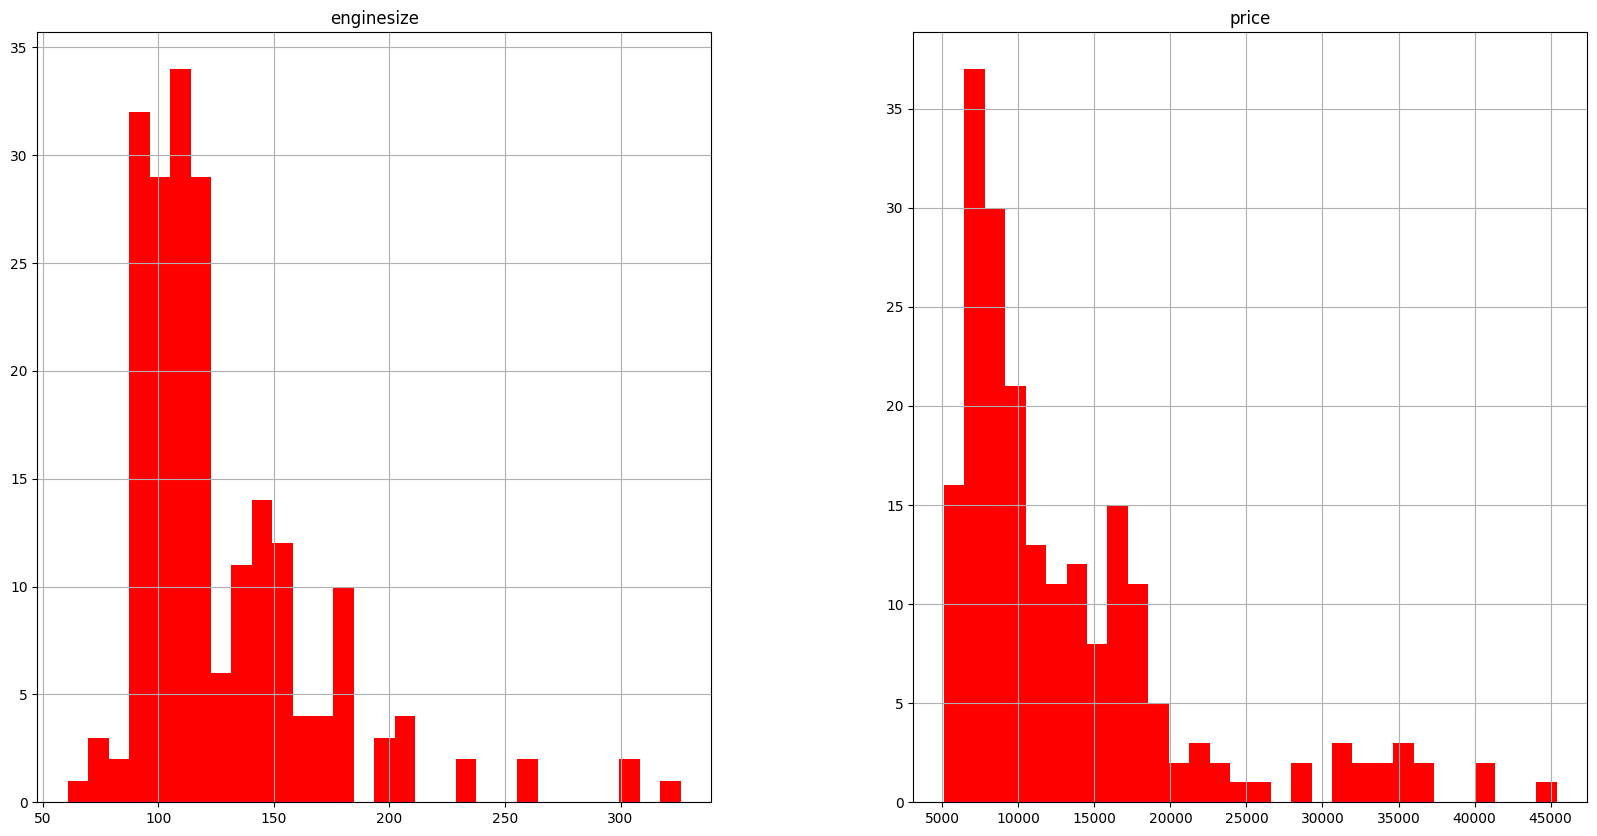

In [ ]:
# Histogram Plotting (Data Distribution)
car_df.hist(bins = 30, figsize = (20,10), color = 'r')

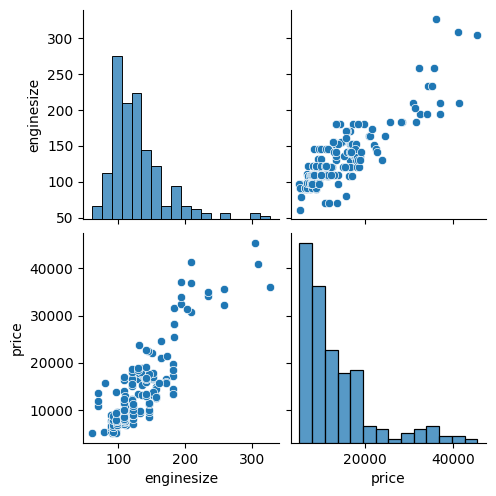

In [9]:
# Plot Pairplot (Variables Relationship)
sns.pairplot(car_df)

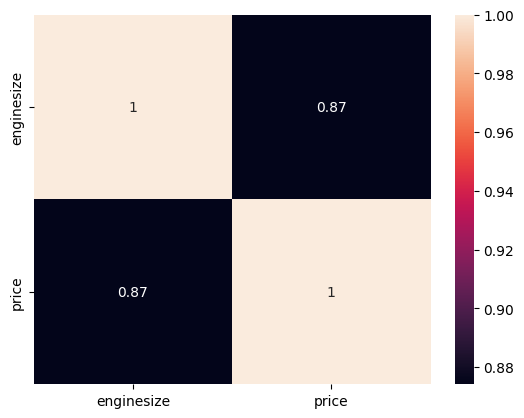

In [12]:
# Correlation Matrix
corr_matrix = car_df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()

In [13]:
# Nilai korelasi Pearson antara enginesize dan price
r = car_df['enginesize'].corr(car_df['price'])
print('Korelasi enginesize dan price (r):', round(r, 4))

Korelasi enginesize dan price (r): 0.8741


<Axes: xlabel='enginesize', ylabel='price'>

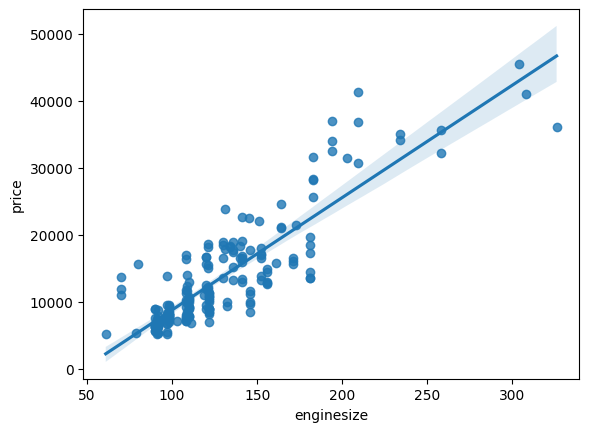

In [14]:
# Regression Plot with Seaborn (straight line fit between "price" and "enginesize")
sns.regplot(x='enginesize', y='price', data=car_df)

## 3) TRAINING AND TESTING DATA

In [15]:
X = car_df[['enginesize']]
y = car_df[['price']]

In [16]:
X

,enginesize
0,130
1,130
2,152
3,109
4,136
...,...
200,141
201,141
202,173
203,145


In [17]:
y

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0
...,...
200,16845.0
201,19045.0
202,21485.0
203,22470.0


In [18]:
X.shape

(205, 1)

In [19]:
y.shape

(205, 1)

In [20]:
X = np.array(X)
y = np.array(y)

In [21]:
X.shape

(205, 1)

In [23]:
# split the data into test and train sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=72)

In [24]:
X_train.shape

(153, 1)

In [26]:
X_test.shape

(52, 1)

In [27]:
print(X)

[[130]
 [130]
 [152]
 [109]
 [136]
 [136]
 [136]
 [136]
 [131]
 [131]
 [108]
 [108]
 [164]
 [164]
 [164]
 [209]
 [209]
 [209]
 [ 61]
 [ 90]
 [ 90]
 [ 90]
 [ 90]
 [ 98]
 [ 90]
 [ 90]
 [ 90]
 [ 98]
 [122]
 [156]
 [ 92]
 [ 92]
 [ 79]
 [ 92]
 [ 92]
 [ 92]
 [ 92]
 [110]
 [110]
 [110]
 [110]
 [110]
 [110]
 [111]
 [ 90]
 [ 90]
 [119]
 [258]
 [258]
 [326]
 [ 91]
 [ 91]
 [ 91]
 [ 91]
 [ 91]
 [ 70]
 [ 70]
 [ 70]
 [ 80]
 [122]
 [122]
 [122]
 [122]
 [122]
 [122]
 [140]
 [134]
 [183]
 [183]
 [183]
 [183]
 [234]
 [234]
 [308]
 [304]
 [140]
 [ 92]
 [ 92]
 [ 92]
 [ 98]
 [110]
 [122]
 [156]
 [156]
 [156]
 [122]
 [122]
 [110]
 [110]
 [ 97]
 [103]
 [ 97]
 [ 97]
 [ 97]
 [ 97]
 [ 97]
 [ 97]
 [ 97]
 [ 97]
 [120]
 [120]
 [181]
 [181]
 [181]
 [181]
 [181]
 [181]
 [120]
 [152]
 [120]
 [152]
 [120]
 [152]
 [120]
 [152]
 [120]
 [152]
 [134]
 [ 90]
 [ 98]
 [ 90]
 [ 90]
 [ 98]
 [122]
 [156]
 [151]
 [194]
 [194]
 [194]
 [203]
 [132]
 [132]
 [121]
 [121]
 [121]
 [121]
 [121]
 [121]
 [ 97]
 [108]
 [108]
 [108]
 [108]

In [28]:
# We can see that data have been shuffled by "train_test_split
X_train

array([[ 97],
       [ 90],
       [ 98],
       [141],
       [ 92],
       [121],
       [108],
       [141],
       [120],
       [130],
       [121],
       [ 91],
       [164],
       [130],
       [152],
       [120],
       [109],
       [122],
       [103],
       [ 98],
       [ 92],
       [152],
       [ 97],
       [130],
       [ 92],
       [110],
       [ 97],
       [134],
       [136],
       [ 92],
       [234],
       [108],
       [209],
       [ 97],
       [122],
       [ 90],
       [ 98],
       [ 70],
       [110],
       [141],
       [108],
       [ 98],
       [108],
       [156],
       [134],
       [120],
       [ 97],
       [181],
       [130],
       [122],
       [152],
       [122],
       [110],
       [ 92],
       [194],
       [136],
       [108],
       [181],
       [258],
       [120],
       [ 92],
       [109],
       [121],
       [ 97],
       [140],
       [ 98],
       [152],
       [146],
       [203],
       [122],
       [108],
      

## 4) Train a Linear Regression Model

In [29]:
# using linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression(fit_intercept = True) # Fit intercept is the "b" parameter (y = b + mx)
lr.fit(X_train, y_train)

LinearRegression()

In [30]:
# Checking the accuracy
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

12352728.737052282

In [31]:
print('Linear Model Coefficient (m): ', lr.coef_)
print('Linear Model Coefficient (b): ', lr.intercept_)

Linear Model Coefficient (m):  [[178.33323087]]
Linear Model Coefficient (b):  [-9116.71681123]


## 5) EVALUATE TRAINED MODEL PERFORMANCE

In [32]:
y_pred

array([[17811.60105016],
       [10678.27181536],
       [ 8181.60658317],
       [10499.93858449],
       [18703.26720451],
       [ 7289.94042882],
       [21378.26566756],
       [10499.93858449],
       [49019.91645244],
       [ 8359.93981404],
       [12639.93735493],
       [ 8359.93981404],
       [ 7289.94042882],
       [16028.26874146],
       [16919.93489581],
       [10499.93858449],
       [16919.93489581],
       [21734.93212931],
       [12639.93735493],
       [10499.93858449],
       [ 6933.27396708],
       [15849.93551059],
       [ 8181.60658317],
       [10143.27212275],
       [21378.26566756],
       [ 7289.94042882],
       [10499.93858449],
       [ 8359.93981404],
       [ 6933.27396708],
       [16028.26874146],
       [23518.26443801],
       [ 6933.27396708],
       [19594.93335886],
       [ 8181.60658317],
       [ 7111.60719795],
       [15136.60258711],
       [ 7289.94042882],
       [ 7289.94042882],
       [10143.27212275],
       [12461.60412406],


In [33]:
# Tambahan: R2 score dan RMSE
from sklearn.metrics import r2_score
print('R2 score :', r2_score(y_test, y_pred))
print('RMSE     :', np.sqrt(mse))

R2 score : 0.7741734286741129
RMSE     : 3514.6448948723514


Text(0.5, 1.0, 'Car Price vs. Engine Size')

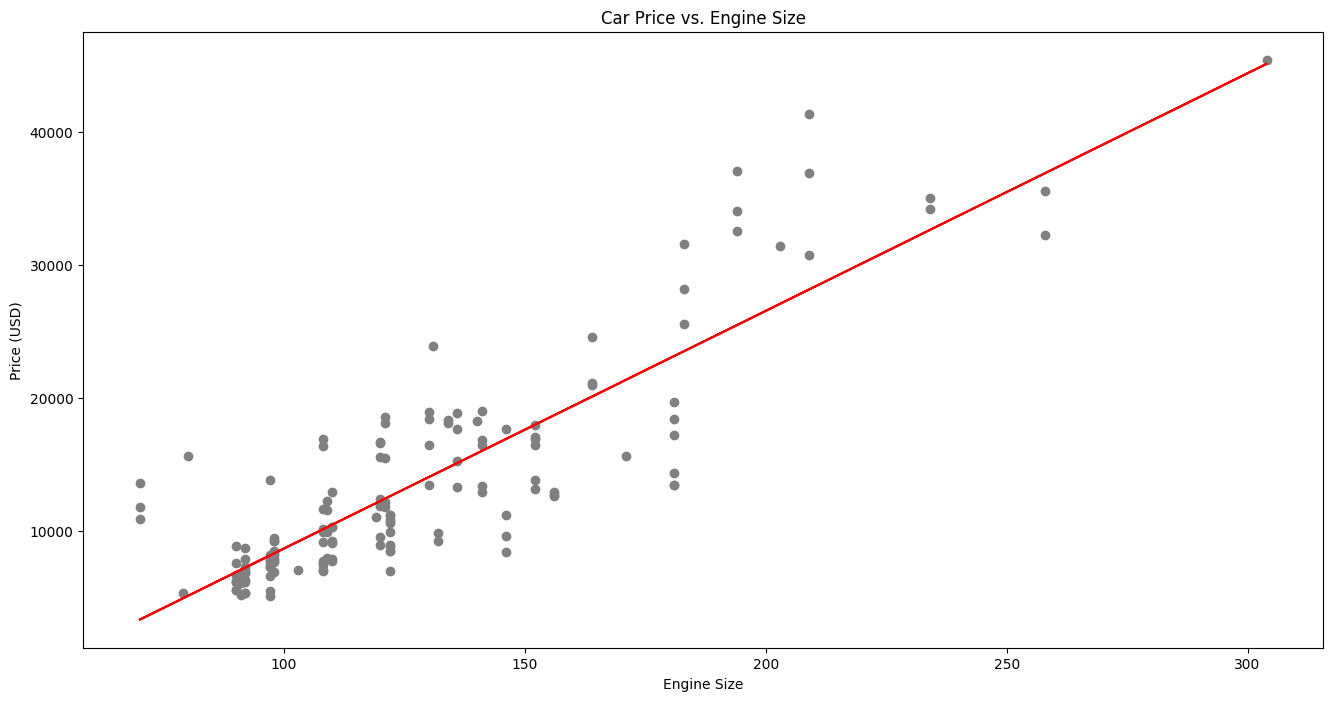

In [35]:
# Plotting the TRAIN DATA
plt.figure(figsize=(16,8))
plt.scatter(X_train, y_train, color = 'gray')
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.ylabel('Price (USD)')
plt.xlabel('Engine Size')
plt.title('Car Price vs. Engine Size')

Text(0.5, 1.0, 'Car Price vs. Engine Size (Test Data)')

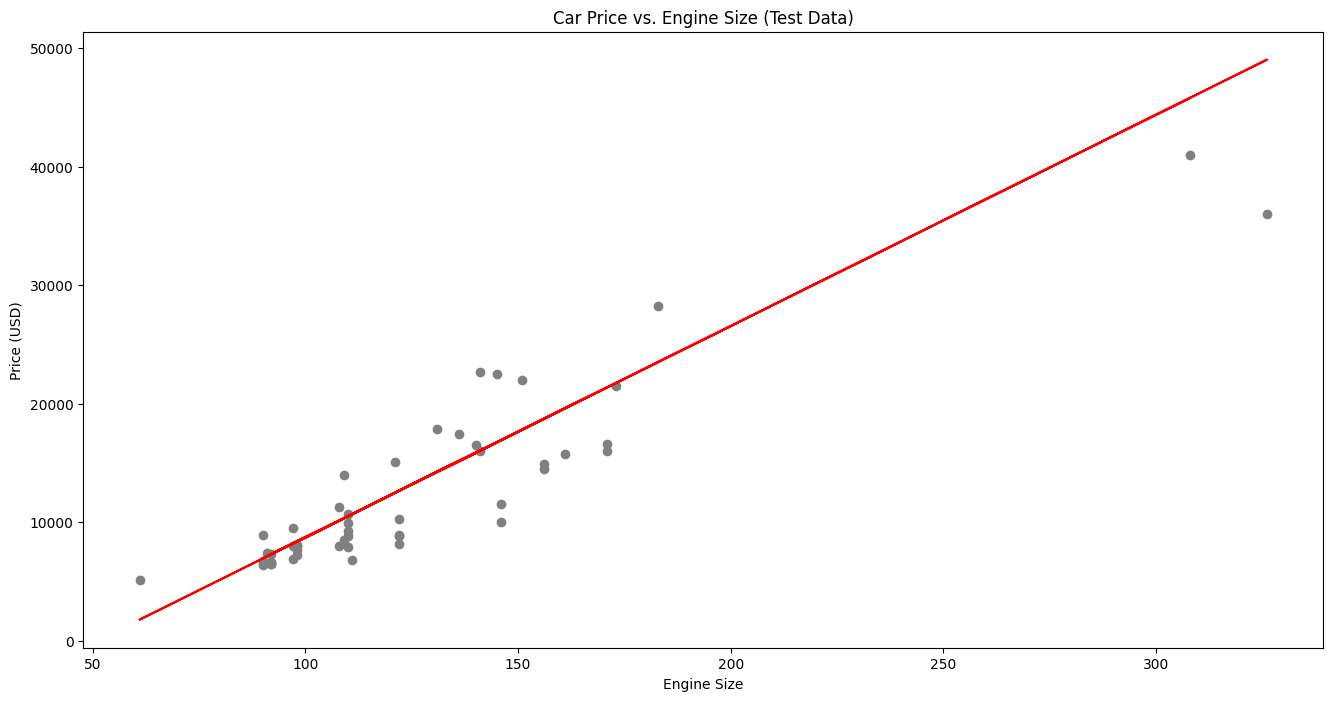

In [36]:
# Plotting the TEST DATA
plt.figure(figsize=(16,8))
plt.scatter(X_test, y_test, color = 'gray')
plt.plot(X_test, y_pred, color = 'red')
plt.ylabel('Price (USD)')
plt.xlabel('Engine Size')
plt.title('Car Price vs. Engine Size (Test Data)')

## 6) Making Predictions
 - Use the trained model to obtain the salary corresponding to eployees who have 5 years of experience

In [37]:
new_value = [[130.0]] # data untuk diprediksi
new_prediction = lr.predict(new_value)
new_prediction

array([[14066.60320189]])

## 7) Save the Model

In [39]:
import joblib

model_file = open("linear_regression_carprice.pkl","wb")
joblib.dump(lr,model_file)
model_file.close()

In [40]:
files.download('linear_regression_carprice.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>